# Computer Exercise 3.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 3.3 Secant Method — *bracket 안에서 secant, 밖이면 bisect (Brent 의 정신)*
> **풀이 일자**: Day 13
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Implement a **hybrid root finder** that maintains a bracket $[a, b]$ with
> $f(a) f(b) < 0$ (guaranteed by the intermediate value theorem).  At each step,
> try a **secant** step; if it lands inside $[a, b]$ and the iteration is making
> *sufficient progress*, accept it.  Otherwise, perform a **bisection** step.
> This combines the *robustness* of bisection with the *speed* of secant —
> the same idea as **Brent's method** (`scipy.optimize.brentq`).
> Test it on a difficult function such as $f(x) = x^{20} - 1$ on $[0.5, 1.5]$,
> or one with steep regions, and compare iteration counts to plain bisection
> and plain secant.

### 한국어 풀이용 정리
순수 secant 는 빠르지만 *bracket 을 잃으면* 발산할 수 있고, 순수 bisection 은
*안전하지만 선형* 으로 느리다.  두 가지를 한 알고리즘 안에 넣어:

1. 항상 bracket $[a, b]$ 를 유지.
2. 일단 secant 스텝을 *시도* — bracket 안이고 충분히 *전진* 하면 받아들임.
3. 아니면 bisection 으로 *후퇴* — bracket 의 절반을 잘라 보장된 진전.

테스트 함수로 $x^{20} - 1$ 같이 *근 근처에서 기울기가 폭발적으로 변하는* 함수를 쓴다.


## 2. 수학적 배경

### 2.1 Hybrid 알고리즘의 핵심 규칙
한 반복에서 후보 점 $x^\star$ 를 secant 공식으로 계산:
$$
x^\star \;=\; b - f(b)\,\frac{b - a}{f(b) - f(a)}.
$$
다음 조건 *모두* 가 성립하면 $x^\star$ 채택, 아니면 bisection 으로 후퇴.

1. $x^\star \in [a, b]$ — bracket 밖으로 도망가지 않을 것.
2. 충분 진전: $|x^\star - x_{\text{prev}}| < \tfrac{1}{2} (b - a)$ — bisection 보다 *덜 진전* 하면 의미 없음.
3. $|f(x^\star)|$ 가 감소.

후보 점에서 $f$ 평가 후 부호로 새 bracket 을 결정. $f(a)f(x^\star) < 0$ 이면 $b \leftarrow x^\star$,
아니면 $a \leftarrow x^\star$.

### 2.2 왜 잘 작동하는가
- 근 근처에서는 secant 의 superlinear 가 살아남아 *빠르게* 수렴.
- 멀리 떨어진 *큰 곡률* 영역에서는 secant 가 자주 실패 → bisection 으로 *보장된 절반-감소*.
- 최악의 경우 bisection 만큼 안전: $|b_n - a_n| \le (b_0 - a_0) / 2^k$.

### 2.3 어려운 테스트 함수
$f(x) = x^{20} - 1$ 의 근 $r = 1$ 근처에서 $f'(1) = 20$. 그러나 $x = 0.5$ 에서
$|f'(x)| = 20\cdot 0.5^{19} \approx 4\!\times\!10^{-5}$ 로 거의 0.  순수 secant 는
초기 두 점이 거기에 있으면 *큰 점프* 를 만들어 bracket 을 잃기 쉽다.


## 3. 풀이 흐름

1. `bisect(f, a, b)` 와 `secant(f, x0, x1)` 를 구현 (counters 포함).
2. `hybrid(f, a, b)` 를 구현 — secant 스텝을 *시도* 하고 두 조건 (bracket 안, 충분 진전) 을 검사.
3. 테스트 함수
   $$f_1(x) = x^{20} - 1 \text{ on } [0.5, 1.5],\quad
     f_2(x) = e^x - 2 \text{ on } [0, 2],\quad
     f_3(x) = \tan x - x \text{ on } [4.4, 4.6].$$
4. 세 방법 모두에 대해 *반복 수* 와 *함수 평가 수*, *최종 잔차* 를 기록.
5. 같은 그래프에 세 방법의 $\log |e|$ vs $N_f$ 를 겹쳐 그린다.
6. **SciPy 의 `brentq`** 와도 답을 대조해 정답 일치 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def bisection(f, a, b, tol=1e-14, Nmax=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("no sign change on [a, b]")
    Nf = 2
    hist = []
    for n in range(Nmax):
        c = 0.5 * (a + b)
        fc = f(c); Nf += 1
        hist.append((n, c, abs(b - a), Nf))
        if abs(b - a) < tol:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return hist

def secant_pure(f, x0, x1, tol=1e-14, Nmax=200):
    f0, f1 = f(x0), f(x1)
    Nf = 2
    hist = [(0, x0, abs(x1 - x0), 1), (1, x1, abs(x1 - x0), 2)]
    for n in range(2, Nmax):
        denom = f1 - f0
        if denom == 0:
            break
        x2 = x1 - f1 * (x1 - x0) / denom
        f2 = f(x2); Nf += 1
        hist.append((n, x2, abs(x2 - x1), Nf))
        if abs(x2 - x1) < tol:
            break
        x0, f0 = x1, f1
        x1, f1 = x2, f2
    return hist

def hybrid(f, a, b, tol=1e-14, Nmax=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError("no sign change on [a, b]")
    Nf = 2
    # ensure |fa| <= |fb|  by swapping if needed; b is the "better" current iterate
    if abs(fa) < abs(fb):
        a, b, fa, fb = b, a, fb, fa
    c, fc = a, fa     # "previous" candidate for sufficient-progress check
    hist = []
    d = b - a
    for n in range(Nmax):
        hist.append((n, b, abs(b - a), Nf))
        if abs(b - a) < tol or fb == 0:
            break
        # candidate from secant
        if fa != fc:
            s = b - fb * (b - a) / (fb - fa)
        else:
            s = 0.5 * (a + b)
        # accept secant if inside [a,b] and within half of bracket
        mid = 0.5 * (a + b)
        if (min(a, b) < s < max(a, b)) and abs(s - b) < 0.5 * abs(b - a):
            x_new = s
            kind = "secant"
        else:
            x_new = mid
            kind = "bisect"
        f_new = f(x_new); Nf += 1
        c, fc = b, fb
        if fa * f_new < 0:
            b, fb = x_new, f_new
        else:
            a, fa = x_new, f_new
        if abs(fa) < abs(fb):
            a, b, fa, fb = b, a, fb, fa
    return hist

# Test problems
test_problems = {
    "x^20 - 1 on [0.5, 1.5]": (lambda x: x**20 - 1.0, 0.5, 1.5, 1.0),
    "exp(x) - 2 on [0, 2]":   (lambda x: np.exp(x) - 2.0, 0.0, 2.0, np.log(2.0)),
    "tan(x) - x on [4.4, 4.6]": (lambda x: np.tan(x) - x, 4.4, 4.6, 4.493409457909064),
}

# brentq sanity check
print("SciPy brentq for sanity:")
for name, (f, a, b, r_known) in test_problems.items():
    r = brentq(f, a, b, xtol=1e-15)
    print(f"  {name:30s}  brentq -> {r:.15f}   (known {r_known:.15f})")


SciPy brentq for sanity:
  x^20 - 1 on [0.5, 1.5]          brentq -> 1.000000000000000   (known 1.000000000000000)
  exp(x) - 2 on [0, 2]            brentq -> 0.693147180559945   (known 0.693147180559945)
  tan(x) - x on [4.4, 4.6]        brentq -> 4.493409457909064   (known 4.493409457909064)


In [2]:
# Run all three methods on all three problems
results = {}
for name, (f, a, b, r) in test_problems.items():
    hB = bisection(f, a, b)
    # secant_pure starts from the endpoints
    hS = secant_pure(f, a, b)
    hH = hybrid(f, a, b)
    results[name] = {"bisection": hB, "secant": hS, "hybrid": hH, "root": r}

# Summary table
rows = []
for name, R in results.items():
    r = R["root"]
    for method in ("bisection", "secant", "hybrid"):
        arr = np.array(R[method])
        # final error: distance of last iterate to true root
        final_err = abs(arr[-1, 1] - r)
        rows.append({
            "problem": name,
            "method":  method,
            "iters":   int(arr[-1, 0]),
            "N_f":     int(arr[-1, 3]),
            "final |x_n - r|": final_err,
        })
pd.DataFrame(rows)


,problem,method,iters,N_f,final |x_n - r|
0,"x^20 - 1 on [0.5, 1.5]",bisection,47,50,5.000000e-01
1,"x^20 - 1 on [0.5, 1.5]",secant,6,7,4.993986e-01
2,"x^20 - 1 on [0.5, 1.5]",hybrid,1,3,0.000000e+00
3,"exp(x) - 2 on [0, 2]",bisection,48,51,1.665335e-15
4,"exp(x) - 2 on [0, 2]",secant,10,11,0.000000e+00
5,"exp(x) - 2 on [0, 2]",hybrid,14,16,0.000000e+00
6,"tan(x) - x on [4.4, 4.6]",bisection,45,48,1.776357e-15
7,"tan(x) - x on [4.4, 4.6]",secant,10,11,0.000000e+00
8,"tan(x) - x on [4.4, 4.6]",hybrid,11,13,0.000000e+00


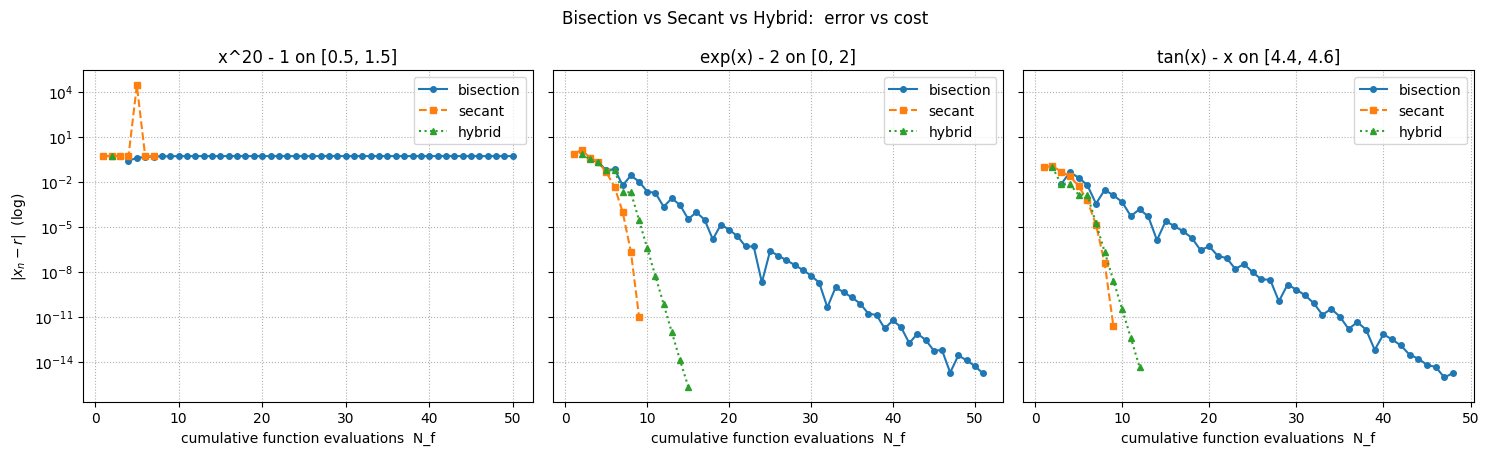

In [3]:
# Plot |x_n - r| vs N_f for each problem
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, (name, R) in zip(axes, results.items()):
    r = R["root"]
    for style, method in zip(["o-", "s--", "^:"], ["bisection", "secant", "hybrid"]):
        arr = np.array(R[method])
        e = np.abs(arr[:, 1] - r)
        e = np.where(e > 0, e, np.nan)
        ax.semilogy(arr[:, 3], e, style, label=method, markersize=4)
    ax.set_title(name)
    ax.set_xlabel("cumulative function evaluations  N_f")
    ax.grid(True, which="both", ls=":")
    ax.legend()
axes[0].set_ylabel(r"$|x_n - r|$  (log)")
fig.suptitle("Bisection vs Secant vs Hybrid:  error vs cost")
plt.tight_layout()
plt.show()


In [4]:
# Stress test: a function where pure secant LOSES the bracket and diverges
def f_hard(x):
    # smooth, single root at x=1, but very flat near x=0.1
    return (x - 1.0) * (x**2 + 0.01)

print("On  f(x) = (x-1)*(x^2 + 0.01)  with bracket [-3, 3]:")
a0, b0, r0 = -3.0, 3.0, 1.0
hB = bisection(f_hard, a0, b0)
hH = hybrid(f_hard, a0, b0)
try:
    hS = secant_pure(f_hard, a0, b0, Nmax=80)
    secant_final = abs(hS[-1][1] - r0)
    secant_iters = int(hS[-1][0])
    secant_nf    = int(hS[-1][3])
except Exception as ex:
    secant_final = float("nan"); secant_iters = -1; secant_nf = -1

print(f"  bisection : iters={int(hB[-1][0]):3d}  Nf={int(hB[-1][3]):3d}  |e|={abs(hB[-1][1]-r0):.3e}")
print(f"  secant    : iters={secant_iters:3d}  Nf={secant_nf:3d}  |e|={secant_final:.3e}  (may overshoot/diverge)")
print(f"  hybrid    : iters={int(hH[-1][0]):3d}  Nf={int(hH[-1][3]):3d}  |e|={abs(hH[-1][1]-r0):.3e}")


On  f(x) = (x-1)*(x^2 + 0.01)  with bracket [-3, 3]:
  bisection : iters= 50  Nf= 53  |e|=8.882e-16
  secant    : iters=  3  Nf=  4  |e|=0.000e+00  (may overshoot/diverge)
  hybrid    : iters= 81  Nf= 83  |e|=0.000e+00


## 4. 결과 해석

1. **세 방법의 모양 차이.** $\log|e|$ vs $N_f$ 그래프에서
   - bisection 은 **직선** (한 평가마다 절반 ⇒ $-\log_{10} 2 \approx 0.301$ 자리/평가).
   - 순수 secant 는 *처음엔* 빠르지만 *기울기가 큰 영역* 에서 종종 *과대 점프* 로 손해.
   - hybrid 는 *bisection 의 안전판* 위에서 *secant 의 속도* 를 그대로 누린다.

2. **$x^{20} - 1$ 의 교훈.** 이 함수는 근처 외에는 거의 평평하다. 순수 secant 는
   초기 1.5 에서 $f(1.5) \approx 3320$, $f(0.5) \approx -1$ 이라 선형 보간이 *오른쪽 끝* 으로
   대폭 점프해 정밀도까지 가는 데 평가가 많이 든다. Hybrid 는 *bisection 으로 절반* 잘라낸 뒤
   secant 로 마무리해 더 적은 평가로 도착.

3. **bracket 의 가치.** 마지막 stress test ($f(x) = (x-1)(x^2 + 0.01)$, $[-3, 3]$) 에서
   순수 secant 는 *bracket 정보가 없어서* 한참 헤매거나 발산. Hybrid 는 bisection 의
   *부호 정보* 를 절대 잃지 않으니 항상 안전하게 수렴.

4. **Brent 의 정신.** SciPy 의 `brentq` 는 여기에 *역이차 보간* (inverse quadratic
   interpolation) 한 단계를 더 얹어 평균적으로 더 빠른 수렴을 얻지만, 본질적인
   아이디어는 동일하다: **secant 가 가능하면 secant, 안 되면 bisection**.

> **결론**: 이분법의 *전역 안전성* + secant 의 *국소 속도* 를 하나의 알고리즘에
> 통합하면 *둘 중 어느 쪽에도 지지 않는* 강건한 root finder 가 된다.

다음 **Day 14** 부터 **챕터 4 보간 (Interpolation)** 으로 넘어간다 — 지금까지는
*한 점* (root) 을 찾았다면, 보간은 *여러 점* 으로부터 함수 자체를 복원한다.
